In [1]:
!pip install face_recognition
!pip install opencv-python
!pip install pandas
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=452879a3ab3295a58a46f3cdab64ea34200e916dae9519df642ae7a786824f69
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [13]:
import face_recognition
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from datetime import datetime
import os

In [9]:
os.makedirs("students", exist_ok=True)

print("Folder created successfully")

Folder created successfully


In [11]:
uploaded = files.upload()

for file_name in uploaded.keys():
    os.rename(file_name, f"students/{file_name}")

print("Student images uploaded")

Saving Ananya.png to Ananya.png
Saving Rahul.png to Rahul.png
Saving Sudeep.png to Sudeep.png
Saving Swetha.png to Swetha.png
Student images uploaded


In [15]:
known_face_encodings = []
known_face_names = []

path = "students"

valid_extensions = (".jpg", ".jpeg", ".png")

for image_name in os.listdir(path):

    # Skip non-image files
    if not image_name.lower().endswith(valid_extensions):
        continue

    image_path = os.path.join(path, image_name)

    print("Processing:", image_path)

    image = face_recognition.load_image_file(image_path)

    encodings = face_recognition.face_encodings(image)

    if len(encodings) > 0:

        encoding = encodings[0]

        known_face_encodings.append(encoding)

        student_name = os.path.splitext(image_name)[0]

        known_face_names.append(student_name)

print("\nFace Encoding Completed")
print(known_face_names)

Processing: students/Rahul.png
Processing: students/Swetha.png
Processing: students/Sudeep.png
Processing: students/Ananya.png

Face Encoding Completed
['Rahul', 'Swetha', 'Sudeep', 'Ananya']


In [16]:
print("Upload classroom image")

uploaded = files.upload()

classroom_image_name = list(uploaded.keys())[0]

print("Uploaded:", classroom_image_name)

Upload classroom image


Saving Group photo.png to Group photo.png
Uploaded: Group photo.png


In [17]:
image = face_recognition.load_image_file(classroom_image_name)

face_locations = face_recognition.face_locations(image)
face_encodings = face_recognition.face_encodings(image, face_locations)

image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

present_students = []

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    matches = face_recognition.compare_faces(
        known_face_encodings,
        face_encoding
    )

    name = "Unknown"

    face_distances = face_recognition.face_distance(
        known_face_encodings,
        face_encoding
    )

    best_match_index = np.argmin(face_distances)

    if matches[best_match_index]:
        name = known_face_names[best_match_index]
        present_students.append(name)

    cv2.rectangle(image_bgr, (left, top), (right, bottom), (0,255,0), 2)

    cv2.putText(
        image_bgr,
        name,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,0),
        2
    )

print("Recognition Completed")

Recognition Completed


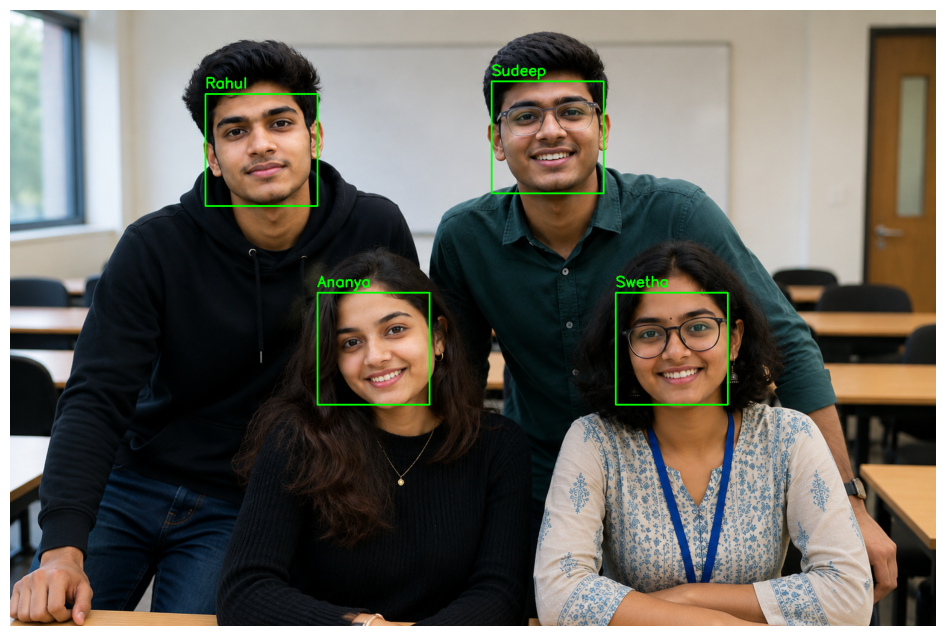

In [18]:
plt.figure(figsize=(12,8))

plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

In [19]:
attendance = []

all_students = known_face_names

present_students = list(set(present_students))

for student in all_students:

    status = "Present" if student in present_students else "Absent"

    attendance.append([student, status])

attendance_df = pd.DataFrame(
    attendance,
    columns=["Student Name", "Attendance"]
)

attendance_df

,Student Name,Attendance
0,Rahul,Present
1,Swetha,Present
2,Sudeep,Present
3,Ananya,Present


In [20]:
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

csv_name = f"attendance_{current_time}.csv"

attendance_df.to_csv(csv_name, index=False)

print("Attendance Saved:", csv_name)

Attendance Saved: attendance_2026-05-15_05-52-53.csv


In [21]:
files.download(csv_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
print("Upload classroom image")

uploaded = files.upload()

classroom_image_name = list(uploaded.keys())[0]

print("Uploaded:", classroom_image_name)

Upload classroom image


Saving Group photo 2.png to Group photo 2.png
Uploaded: Group photo 2.png


In [23]:
image = face_recognition.load_image_file(classroom_image_name)

face_locations = face_recognition.face_locations(image)
face_encodings = face_recognition.face_encodings(image, face_locations)

image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

present_students = []

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    matches = face_recognition.compare_faces(
        known_face_encodings,
        face_encoding
    )

    name = "Unknown"

    face_distances = face_recognition.face_distance(
        known_face_encodings,
        face_encoding
    )

    best_match_index = np.argmin(face_distances)

    if matches[best_match_index]:
        name = known_face_names[best_match_index]
        present_students.append(name)

    cv2.rectangle(image_bgr, (left, top), (right, bottom), (0,255,0), 2)

    cv2.putText(
        image_bgr,
        name,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,0),
        2
    )

print("Recognition Completed")

Recognition Completed


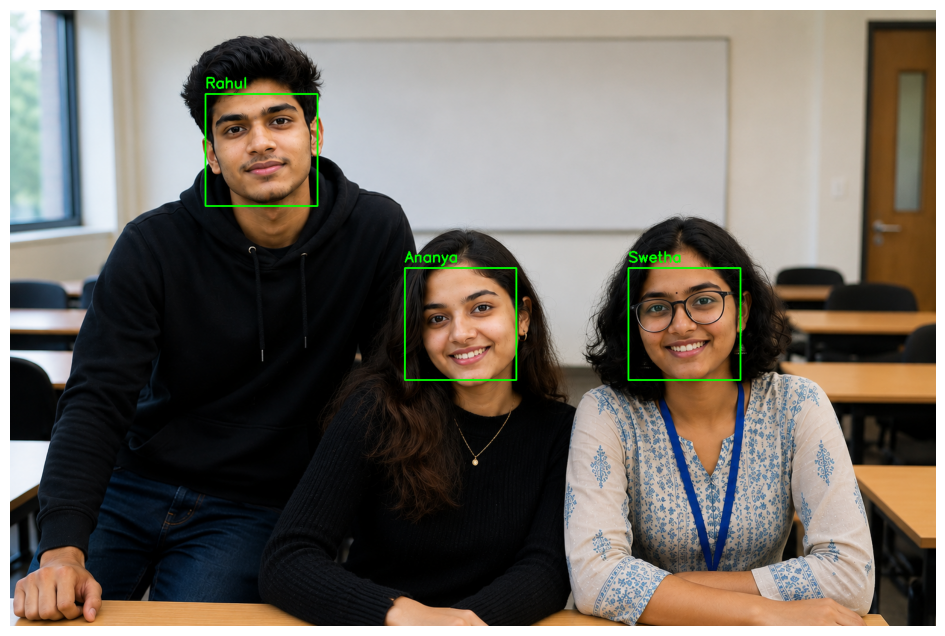

In [24]:
plt.figure(figsize=(12,8))

plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

In [25]:
attendance = []

all_students = known_face_names

present_students = list(set(present_students))

for student in all_students:

    status = "Present" if student in present_students else "Absent"

    attendance.append([student, status])

attendance_df = pd.DataFrame(
    attendance,
    columns=["Student Name", "Attendance"]
)

attendance_df

,Student Name,Attendance
0,Rahul,Present
1,Swetha,Present
2,Sudeep,Absent
3,Ananya,Present


In [26]:
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

csv_name = f"attendance_{current_time}.csv"

attendance_df.to_csv(csv_name, index=False)

print("Attendance Saved:", csv_name)

Attendance Saved: attendance_2026-05-15_05-57-17.csv


In [27]:
files.download(csv_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>